## Проект "Викишоп" с BERT

Интернет-магазин «Викишоп» запускает сервис с пользовательскими правками описаний товаров. Нужно автоматически находить токсичные комментарии и отправлять их на модерацию.

Цель проекта: обучить модель бинарной классификации токсичности (`toxic`) по тексту комментария (`text`) и получить значение метрики *F1* не ниже `0.75`.

План работы:
1. Подготовка и первичная проверка данных.
2. Исследовательский анализ текстов.
3. Baseline-модель (TF-IDF + LogisticRegression).
4. BERT-подход и сравнение результатов.

**Описание данных**

Файл: `toxic_comments.csv`.
- `text` — текст комментария;
- `toxic` — целевой признак (0/1).


In [ ]:
pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Загрузка и подготовка данных

In [2]:
!pip install scikit-learn

Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 4, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 19, in <module>
    from pip._internal.cli.spinners import open_spinner
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/spinners.py", line 9, in <module>
    from pip._internal.utils.logging import get_indentation
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/util

In [5]:
# импортируем все необходимые библиотеки
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import torch
from transformers import AutoModel, AutoTokenizer
import numpy as np
from tqdm import notebook

In [3]:
from google.colab import files
uploaded = files.upload()

Saving toxic_comments.csv to toxic_comments.csv


In [6]:
# прочитаем файл с комментариями
toxic_comments = pd.read_csv('toxic_comments.csv', index_col=0)

In [7]:
# выведем первые 5 строк датафрейма
toxic_comments.head()

,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [8]:
toxic_comments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB


In [9]:
toxic_comments.duplicated().sum()

np.int64(0)

## Исследовательский анализ данных (EDA)

Проверим баланс классов и базовые характеристики длины текстов, построим гистограммы и boxplot, затем кратко сформулируем выводы для выбора baseline и стратегии валидации.

In [14]:
# EDA (1/5): подготовка данных для анализа
text_col = "text"
target_col = "toxic"

if text_col not in toxic_comments.columns or target_col not in toxic_comments.columns:
    raise ValueError(
        f"Ожидались столбцы '{text_col}' и '{target_col}', но получены: {list(toxic_comments.columns)}"
    )

eda_df = toxic_comments[[text_col, target_col]].copy()
eda_df[text_col] = eda_df[text_col].astype(str)
eda_df["text_len_chars"] = eda_df[text_col].str.len()
eda_df["text_len_words"] = eda_df[text_col].str.split().str.len()

display(eda_df.head())

,text,toxic,text_len_chars,text_len_words
0,Explanation\nWhy the edits made under my usern...,0,264,43
1,D'aww! He matches this background colour I'm s...,0,112,17
2,"Hey man, I'm really not trying to edit war. It...",0,233,42
3,"""\nMore\nI can't make any real suggestions on ...",0,622,113
4,"You, sir, are my hero. Any chance you remember...",0,67,13


In [16]:
# EDA (2/5): размер датасета и баланс классов
print("Размер датасета:", eda_df.shape)

print("\nБаланс классов (доли):")
print(eda_df[target_col].value_counts(normalize=True).sort_index().round(4))

print("\nБаланс классов (абсолютные):")
print(eda_df[target_col].value_counts().sort_index())

Размер датасета: (159292, 4)

Баланс классов (доли):
toxic
0    0.8984
1    0.1016
Name: proportion, dtype: float64

Баланс классов (абсолютные):
toxic
0    143106
1     16186
Name: count, dtype: int64


In [17]:
# EDA (3/5): длины текстов (числа)
print("Статистика длины текста (символы):")
print(eda_df["text_len_chars"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))

print("\nСтатистика длины текста (слова):")
print(eda_df["text_len_words"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))

Статистика длины текста (символы):
count    159292.00
mean        393.69
std         590.11
min           5.00
50%         205.00
90%         889.00
95%        1354.00
99%        3441.09
max        5000.00
Name: text_len_chars, dtype: float64

Статистика длины текста (слова):
count    159292.00
mean         67.21
std          99.13
min           1.00
50%          36.00
90%         152.00
95%         229.00
99%         567.00
max        1411.00
Name: text_len_words, dtype: float64


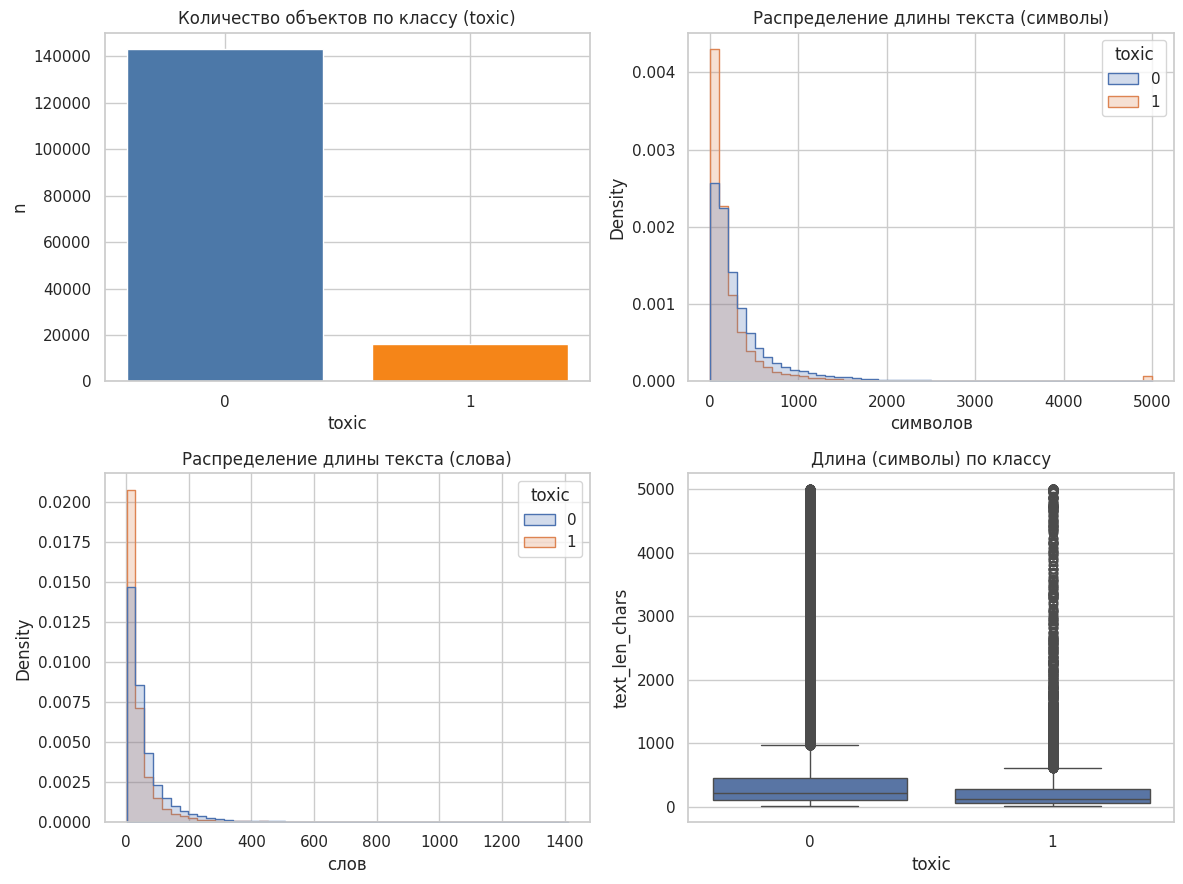

In [18]:
# EDA (4/5): визуализации
sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

vc = eda_df[target_col].value_counts().sort_index()
axes[0, 0].bar(vc.index.astype(str), vc.values, color=["#4C78A8", "#F58518"])
axes[0, 0].set_title("Количество объектов по классу (toxic)")
axes[0, 0].set_xlabel("toxic")
axes[0, 0].set_ylabel("n")

sns.histplot(
    data=eda_df,
    x="text_len_chars",
    hue=target_col,
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Распределение длины текста (символы)")
axes[0, 1].set_xlabel("символов")

sns.histplot(
    data=eda_df,
    x="text_len_words",
    hue=target_col,
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Распределение длины текста (слова)")
axes[1, 0].set_xlabel("слов")

sns.boxplot(data=eda_df, x=target_col, y="text_len_chars", ax=axes[1, 1])
axes[1, 1].set_title("Длина (символы) по классу")
axes[1, 1].set_xlabel("toxic")

plt.tight_layout()
plt.show()

In [19]:
# EDA (5/5): примеры и краткие выводы
print("Примеры самых коротких комментариев:")
display(eda_df.nsmallest(5, "text_len_chars")[[text_col, target_col, "text_len_chars"]])

print("\nПримеры самых длинных комментариев:")
display(eda_df.nlargest(5, "text_len_chars")[[text_col, target_col, "text_len_chars"]])

counts = eda_df[target_col].value_counts().sort_index()
props = eda_df[target_col].value_counts(normalize=True).sort_index()
minority_label = props.idxmin()
minority_share = props.min()
med_chars_t0 = eda_df.loc[eda_df[target_col] == 0, "text_len_chars"].median()
med_chars_t1 = eda_df.loc[eda_df[target_col] == 1, "text_len_chars"].median()

print("\n--- Краткие выводы по EDA ---")
print(
    f"• Классы: toxic=0 — {counts.get(0, 0)} ({props.get(0, 0):.1%}), "
    f"toxic=1 — {counts.get(1, 0)} ({props.get(1, 0):.1%}). "
    f"Меньший класс — {minority_label} (~{minority_share:.1%} выборки)."
)
print(
    f"• Медианная длина (символы): toxic=0 → {med_chars_t0:.0f}, toxic=1 → {med_chars_t1:.0f}."
)
print(
    "• Практически: stratified train/test split + учёт дисбаланса (class_weight) полезны; "
    "для BERT max_length=512 обычно достаточно, но можно ориентироваться на перцентили."
)

Примеры самых коротких комментариев:


,text,toxic,text_len_chars
119123,"""""""",1,5
52393,"14:53,",0,6
136958,~ J.Lo,0,6
137547,"== """"""",0,6
15449,"Howdy!""",0,7



Примеры самых длинных комментариев:


,text,toxic,text_len_chars
4167,ii CAN STILL POST WITH THIS COMPUTER...I SAID ...,1,5000
6194,SECURITYFUCK HOMELAND SECURITYFUCK HOMELAND SE...,1,5000
8697,BALLS BALLS BALLS BALLS BALLS BALLS BALLS BALL...,1,5000
9664,"FUCK YOU, YOU ATHEIST CUNT! FUCK YOU, YOU ATHE...",1,5000
10759,TOMMY2010 IS A NIGGER TOMMY2010 IS A NIGGER TO...,1,5000



--- Краткие выводы по EDA ---
• Классы: toxic=0 — 143106 (89.8%), toxic=1 — 16186 (10.2%). Меньший класс — 1 (~10.2% выборки).
• Медианная длина (символы): toxic=0 → 216, toxic=1 → 128.
• Практически: stratified train/test split + учёт дисбаланса (class_weight) полезны; для BERT max_length=512 обычно достаточно, но можно ориентироваться на перцентили.


## Baseline: TF-IDF + LogisticRegression

Построим быстрый baseline на TF-IDF признаках с `stratified` train/test split и оценим качество по `F1` и `classification_report`.

In [20]:
# baseline: TF-IDF + LogisticRegression
X = toxic_comments[text_col].astype(str)
y = toxic_comments[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

vectorizer = TfidfVectorizer(min_df=3, ngram_range=(1, 2), max_features=100000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
)
baseline_model.fit(X_train_tfidf, y_train)

y_pred = baseline_model.predict(X_test_tfidf)

f1 = f1_score(y_test, y_pred)
print(f"F1 (test): {f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

F1 (test): 0.7577

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     28622
           1       0.68      0.85      0.76      3237

    accuracy                           0.94     31859
   macro avg       0.83      0.90      0.86     31859
weighted avg       0.95      0.94      0.95     31859



## BERT-подход

После baseline переходим к получению эмбеддингов BERT и дальнейшему обучению модели на них.

In [10]:
# загрузка предобученной BERT-модели и токенизатора
model_name = "bert-base-cased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
model = AutoModel.from_pretrained(model_name)
model = model.to(device)
model.eval()

device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [11]:
def compute_bert_mean_pool_embeddings(
    model,
    tokenizer,
    texts,
    device,
    batch_size=32,
    max_length=512,
    show_progress=True,
    use_fp16=None,
):
    """Считает эмбеддинги документов: mean pooling по токенам с учётом attention_mask.
    Токенизация идёт по батчам — без одного огромного encoded-тензора на весь датасет."""
    model.eval()
    if not isinstance(texts, (list, tuple)):
        texts = list(texts)
    n_samples = len(texts)
    if use_fp16 is None:
        use_fp16 = device.type == "cuda" and torch.cuda.is_available()

    num_batches = (n_samples + batch_size - 1) // batch_size
    batch_indices = range(num_batches)
    if show_progress:
        batch_indices = notebook.tqdm(batch_indices)

    out_chunks = []
    with torch.no_grad():
        for b in batch_indices:
            start = b * batch_size
            end = min(start + batch_size, n_samples)
            batch_texts = texts[start:end]
            encoded = tokenizer(
                batch_texts,
                add_special_tokens=True,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )
            batch_ids = encoded["input_ids"].to(device)
            batch_mask = encoded["attention_mask"].to(device)

            if use_fp16 and device.type == "cuda":
                with torch.autocast("cuda", dtype=torch.float16):
                    outputs = model(input_ids=batch_ids, attention_mask=batch_mask)
            else:
                outputs = model(input_ids=batch_ids, attention_mask=batch_mask)
            token_embeddings = outputs.last_hidden_state

            mask_float = batch_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            summed = (token_embeddings * mask_float).sum(dim=1)
            counts = mask_float.sum(dim=1).clamp(min=1e-9)
            mean_pooled = summed / counts

            out_chunks.append(mean_pooled.cpu().numpy())

    return np.concatenate(out_chunks, axis=0)

In [12]:
features = compute_bert_mean_pool_embeddings(
    model,
    tokenizer,
    toxic_comments["text"].tolist(),
    device=device,
    batch_size=32,
    max_length=512,
)
print("Shape of BERT features:", features.shape)

  0%|          | 0/4978 [00:00<?, ?it/s]

Shape of BERT features: (159292, 768)


In [15]:
# классификация на BERT-эмбеддингах + оценка качества
X_bert = features
y_bert = toxic_comments[target_col]

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert,
    y_bert,
    test_size=0.2,
    random_state=42,
    stratify=y_bert,
)

bert_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
)
bert_clf.fit(X_train_bert, y_train_bert)

y_pred_bert = bert_clf.predict(X_test_bert)

f1_bert = f1_score(y_test_bert, y_pred_bert)
print(f"BERT embeddings + LogisticRegression | F1 (test): {f1_bert:.4f}")
print("\nClassification report (BERT features):")
print(classification_report(y_test_bert, y_pred_bert))

BERT embeddings + LogisticRegression | F1 (test): 0.6700

Classification report (BERT features):
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     28622
           1       0.53      0.90      0.67      3237

    accuracy                           0.91     31859
   macro avg       0.76      0.90      0.81     31859
weighted avg       0.94      0.91      0.92     31859

